# OpenSearch Queries

This notebook demonstrates OpenSearch-style financial document queries using offline pandas filters and simple text retrieval.

Abbreviations used in this notebook:

- **API**: Application Programming Interface.
- **JSON**: JavaScript Object Notation.
- **RAG**: Retrieval-Augmented Generation.
- **ID**: Identifier.
- **OHLCV**: Open, High, Low, Close, Volume.

## 1. Intuition

Search systems combine metadata filters with text relevance. For financial research, filters such as ticker, source, date, and section prevent the system from mixing unrelated companies or document types.

## 2. Mathematics

A filtered query can be represented as:

$$
Results = Documents[Metadata\ Filter] \cap TopK(Text\ Similarity)
$$

The document identifier should be deterministic:

$$
ID = Ticker + Source + Date + Section
$$

## 3. Implementation

We build JSON-like query dictionaries, apply metadata filters, and rank filtered documents by retrieval score.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "06_ai_agents" / "ai_utils.py"
spec = importlib.util.spec_from_file_location("ai_utils", helper_path)
ai_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ai_utils)

plt.style.use("seaborn-v0_8-whitegrid")
documents = ai_utils.sample_financial_documents()

query = {
    "ticker": "NESN.SW",
    "source": None,
    "section": "risk",
    "text": "commodity inflation currency volatility regulatory risk",
    "top_k": 3,
}
query

{'ticker': 'NESN.SW',
 'source': None,
 'section': 'risk',
 'text': 'commodity inflation currency volatility regulatory risk',
 'top_k': 3}

In [2]:
filtered = ai_utils.opensearch_like_filter(documents, ticker=query["ticker"], source=query["source"], section=query["section"])
ranked = ai_utils.retrieve(filtered, query["text"], top_k=query["top_k"])
ranked[["doc_id", "ticker", "source", "section", "score", "text"]]

,doc_id,ticker,source,section,score,text
0,nestle_risk_2024,NESN.SW,risk_factors,risk,0.534522,"Key risks include commodity inflation, foreign..."


In [3]:
def to_query_dsl(query):
    filters = []
    for field in ["ticker", "source", "section"]:
        if query.get(field):
            filters.append({"term": {field: query[field]}})
    return {
        "query": {
            "bool": {
                "filter": filters,
                "must": [{"match": {"text": query["text"]}}],
            }
        },
        "size": query["top_k"],
    }

to_query_dsl(query)

{'query': {'bool': {'filter': [{'term': {'ticker': 'NESN.SW'}},
    {'term': {'section': 'risk'}}],
   'must': [{'match': {'text': 'commodity inflation currency volatility regulatory risk'}}]}},
 'size': 3}

## 4. Visualization

Query diagnostics should show how many documents survive each filter.

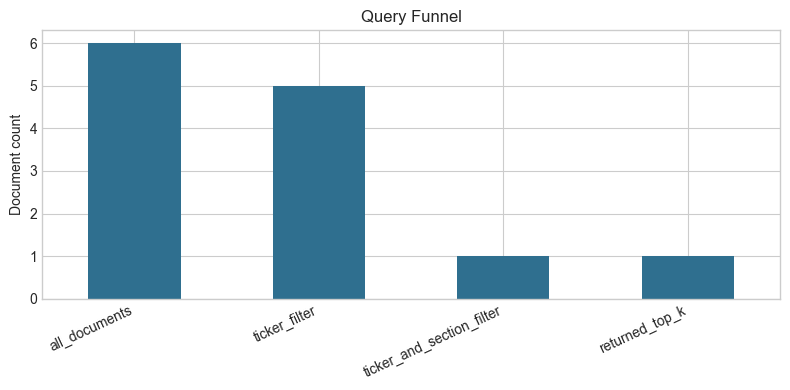

In [4]:
steps = pd.Series({
    "all_documents": len(documents),
    "ticker_filter": len(ai_utils.opensearch_like_filter(documents, ticker="NESN.SW")),
    "ticker_and_section_filter": len(filtered),
    "returned_top_k": len(ranked),
})

fig, ax = plt.subplots(figsize=(8, 4))
steps.plot(kind="bar", ax=ax, color="#2f6f8f")
ax.set_title("Query Funnel")
ax.set_ylabel("Document count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout(); plt.show()

## 5. Application

OpenSearch-style queries are useful when an AI agent needs to retrieve scoped evidence: only one ticker, only risk sections, only recent reports, or only model assumptions.

In [5]:
query_examples = pd.DataFrame([
    {"use_case": "Valuation evidence", "filter": "ticker=NESN.SW, section=dcf"},
    {"use_case": "Risk review", "filter": "ticker=NESN.SW, section=risk"},
    {"use_case": "Peer comparison", "filter": "source=analyst_note"},
])
query_examples

,use_case,filter
0,Valuation evidence,"ticker=NESN.SW, section=dcf"
1,Risk review,"ticker=NESN.SW, section=risk"
2,Peer comparison,source=analyst_note


## 6. Reflection

- Metadata filters are as important as text similarity.
- Query diagnostics reveal whether filters are too narrow.
- Deterministic IDs prevent duplicate indexing.
- Search design shapes agent behavior.

Questions to answer after running the notebook:

1. Which filter removed the most documents?
2. Why filter by ticker before retrieval?
3. What fields would you add to the index mapping?
4. How could a bad query mislead an agent?